# Template Pengerjaan Tugas Supervised Learning

In [83]:
# Data handling
import pandas as pd
import numpy as np

# Visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Import Dataset dari Kaggle
- Akses situs Kaggle dan cari dataset yang relevan untuk tugas Supervised Learning.
- Unduh dataset menggunakan Kaggle API (jika tersedia) atau secara manual dengan mengklik tombol download pada halaman dataset.
- Simpan dataset ke dalam folder proyek dan pastikan format file sesuai (misalnya CSV atau ZIP yang perlu diekstrak).
- Load dataset ke dalam environment kerja menggunakan library yang sesuai, dan periksa struktur data awal seperti jumlah baris, kolom, dan tipe data.

In [84]:
data = pd.read_csv("diabetes.csv")

print(data.head())
print(data.info())

print("Shape:", data.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

## 2. EDA (Exploratory Data Analysis)
- Lakukan analisis deskriptif untuk memahami distribusi data, termasuk statistik dasar seperti mean, median, mode, dan standar deviasi untuk setiap fitur.
- Visualisasikan data menggunakan plot seperti histogram, boxplot, scatter plot, atau heatmap korelasi untuk mengidentifikasi pola, outlier, dan hubungan antar variabel.
- Periksa missing values, duplikasi data, dan imbalance pada target variable jika ada.
- Identifikasi fitur-fitur penting yang mungkin mempengaruhi model berdasarkan analisis ini.

In [85]:
# statistik dasar
print(data.describe())

# mean
print("\nMean:\n", data.mean())

# median
print("\nMedian:\n", data.median())

# mode
print("\nMode:\n", data.mode().iloc[0])

# standar deviasi
print("\nStd Dev:\n", data.std())

print("\nJumlah Null:\n", data.isnull().sum())

print("\nJumlah Duplikat:\n", data.duplicated().sum())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

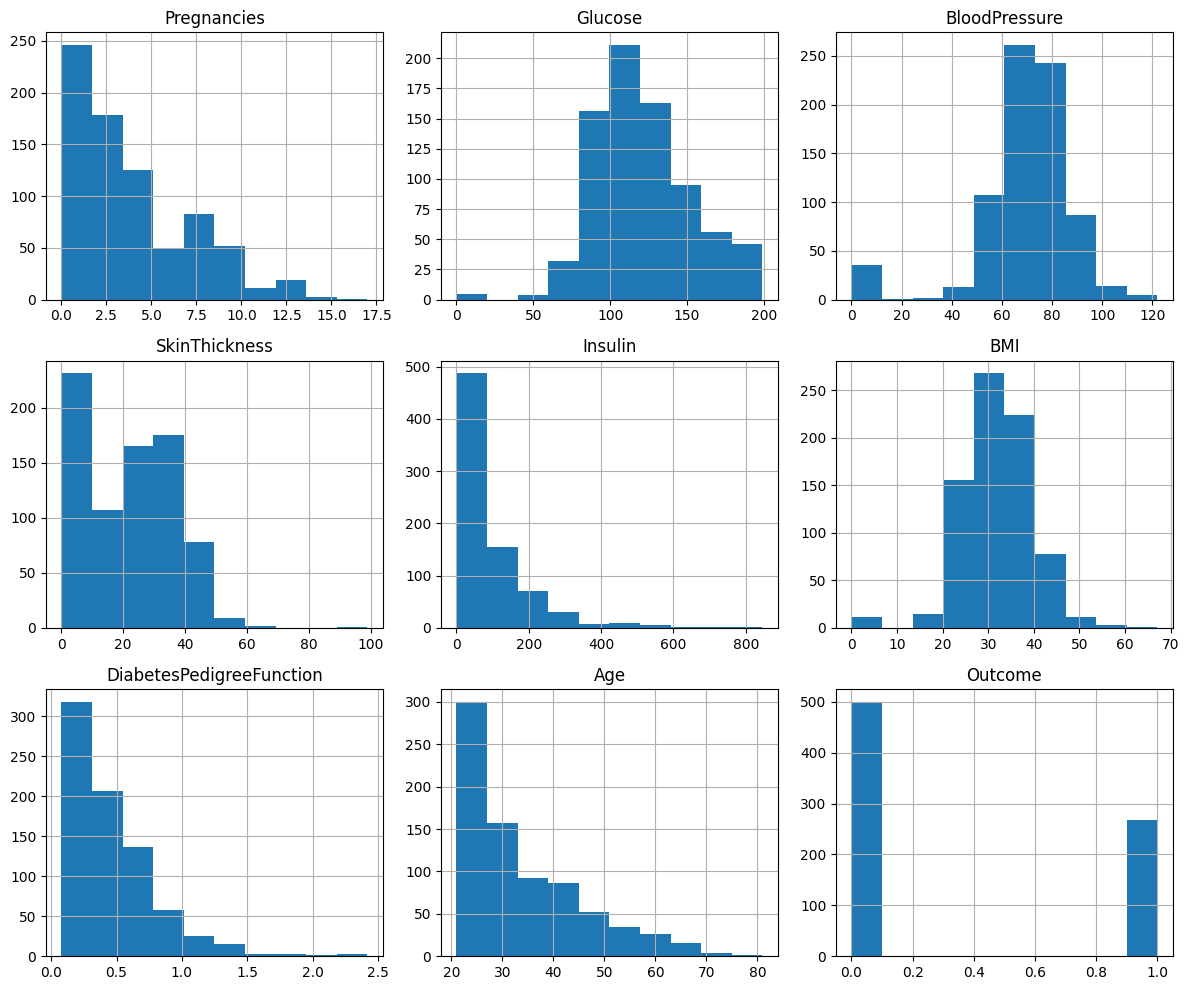

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

data.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

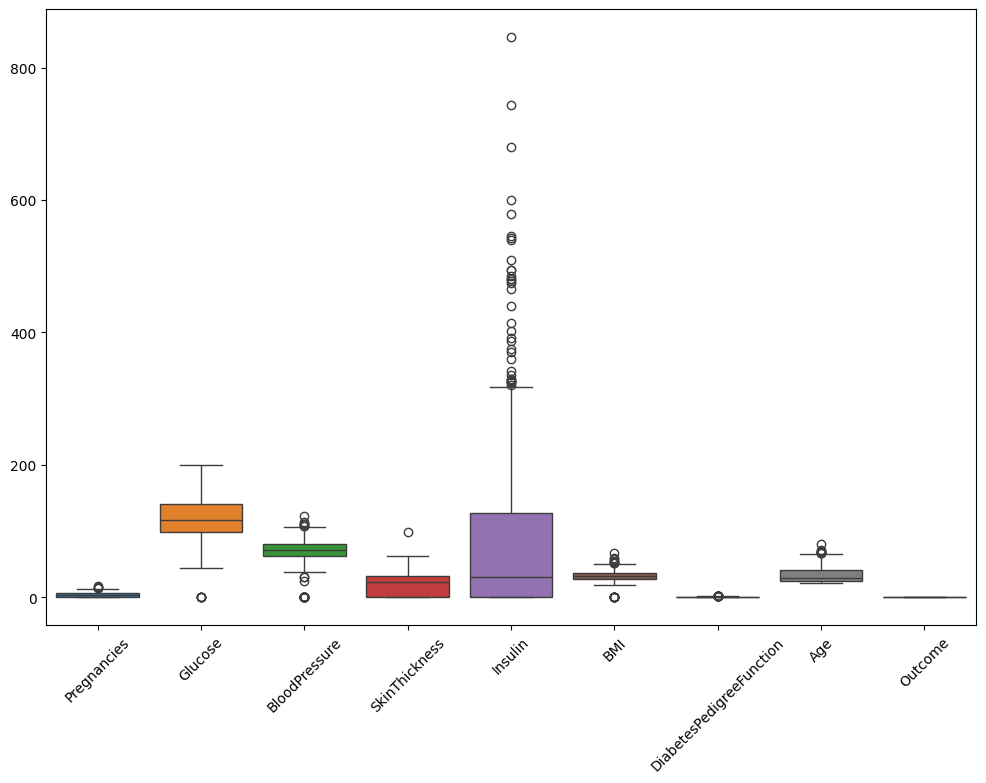

In [87]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()

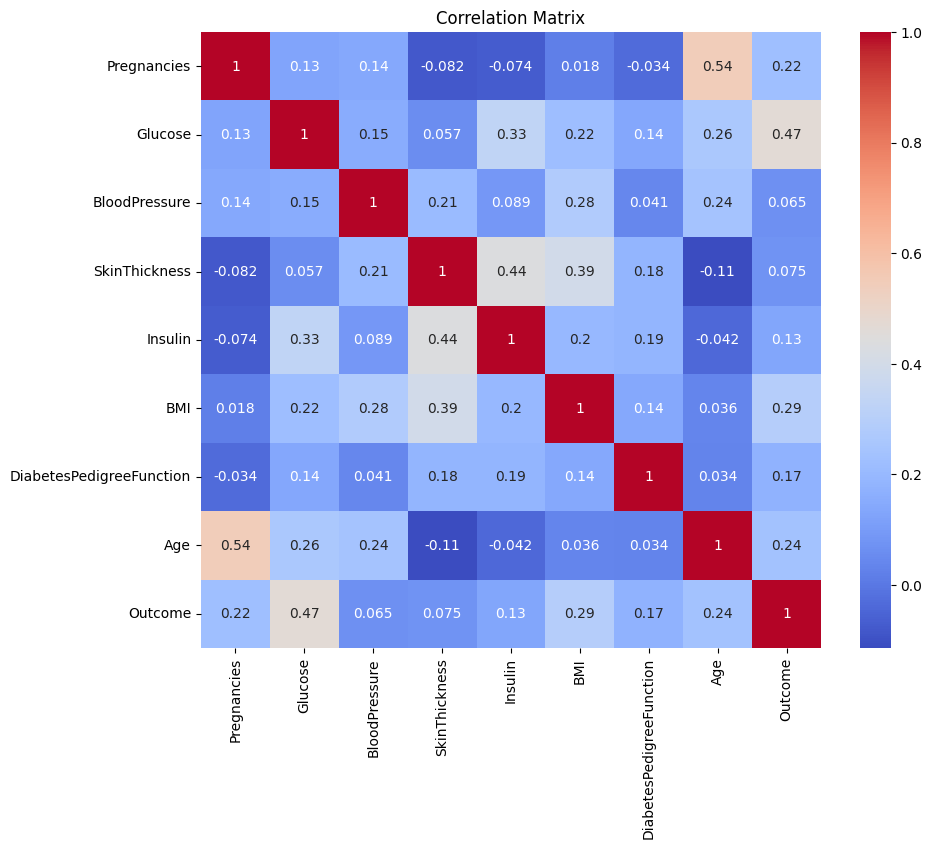

In [88]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

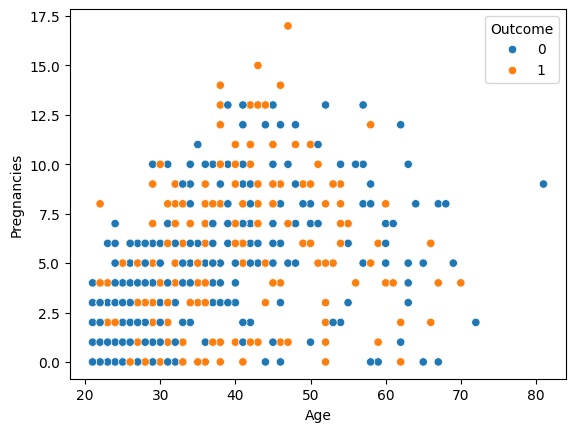

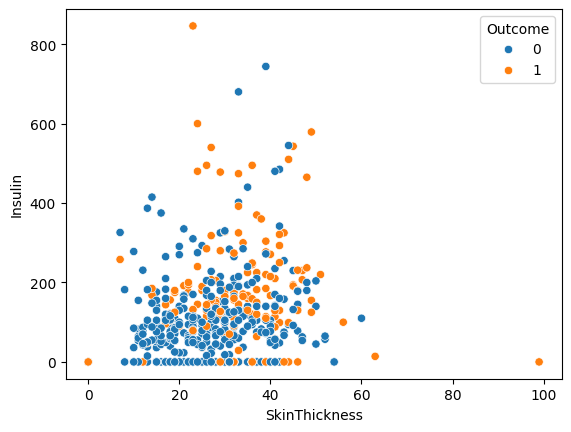

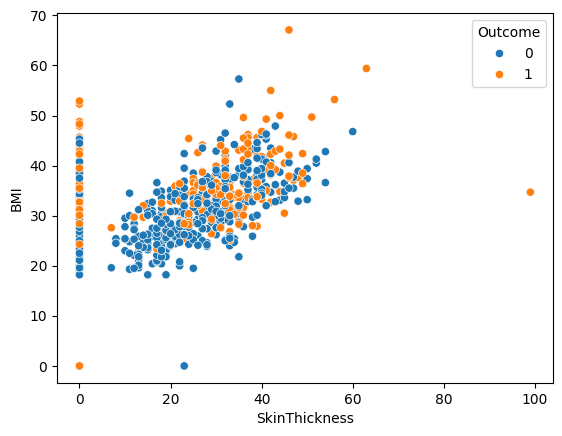

In [89]:
sns.scatterplot(x="Age", y="Pregnancies", hue="Outcome", data=data)
plt.show()

sns.scatterplot(x="SkinThickness", y="Insulin", hue="Outcome", data=data)
plt.show()

sns.scatterplot(x="SkinThickness", y="BMI", hue="Outcome", data=data)
plt.show()

In [90]:
# missing value
print(data.isnull().sum())

# cek nilai 0 (yang mencurigakan)
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    print(f"{col} zero count:", (data[col] == 0).sum())

print("Duplicate rows:", data.duplicated().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose zero count: 5
BloodPressure zero count: 35
SkinThickness zero count: 227
Insulin zero count: 374
BMI zero count: 11
Duplicate rows: 0


Outcome
0    500
1    268
Name: count, dtype: int64


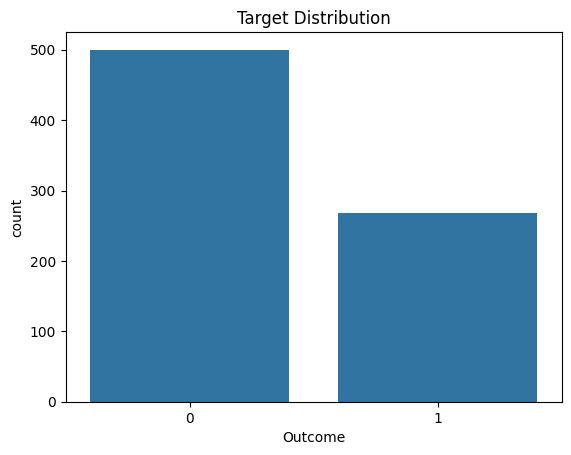

In [91]:
print(data["Outcome"].value_counts())

sns.countplot(x="Outcome", data=data)
plt.title("Target Distribution")
plt.show()

         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
Outcome                                                                      
0           3.298000  109.980000      68.184000      19.664000   68.792000   
1           4.865672  141.257463      70.824627      22.164179  100.335821   

               BMI  DiabetesPedigreeFunction        Age  
Outcome                                                  
0        30.304200                  0.429734  31.190000  
1        35.142537                  0.550500  37.067164  


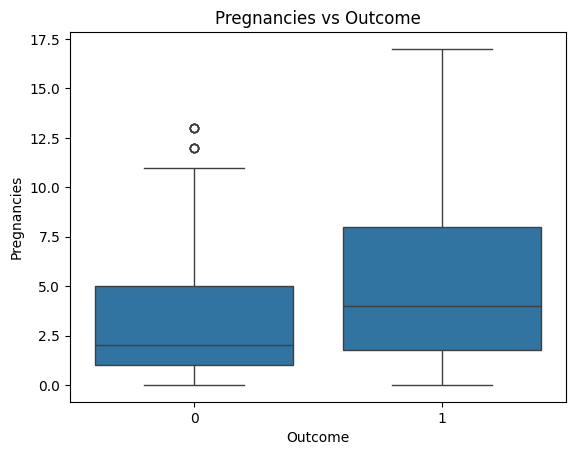

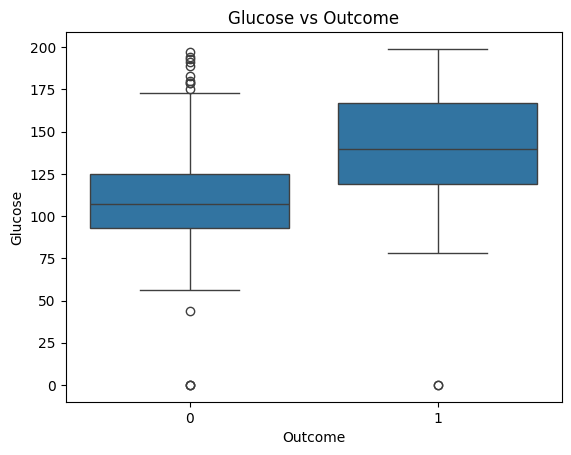

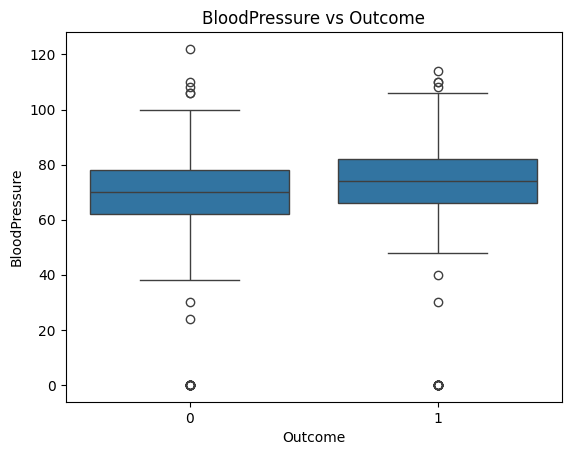

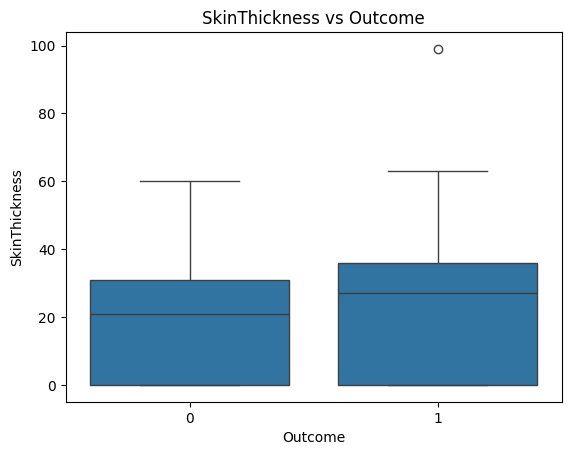

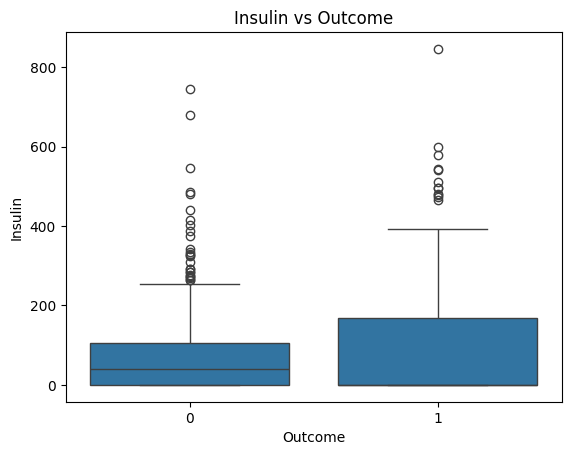

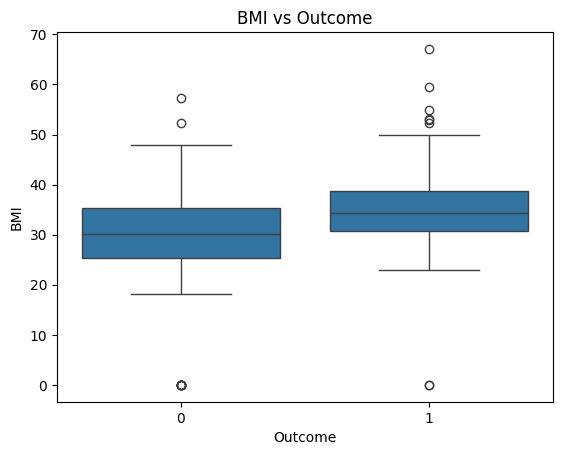

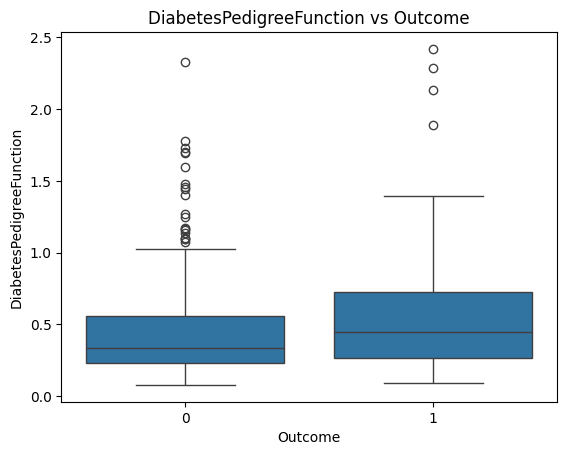

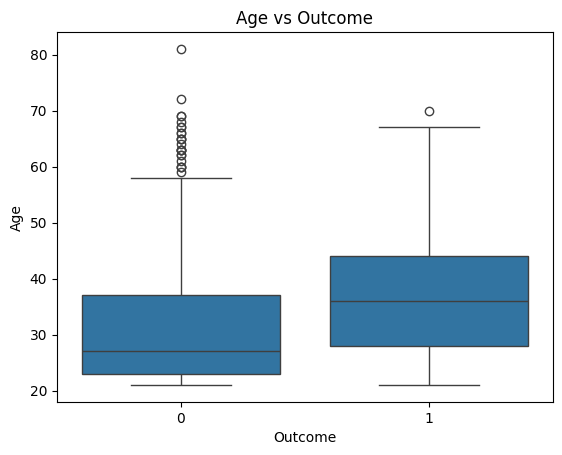

In [92]:
# rata-rata tiap fitur berdasarkan Outcome
print(data.groupby("Outcome").mean())

features = data.columns[:-1]

for col in features:
    sns.boxplot(x="Outcome", y=col, data=data)
    plt.title(f"{col} vs Outcome")
    plt.show()

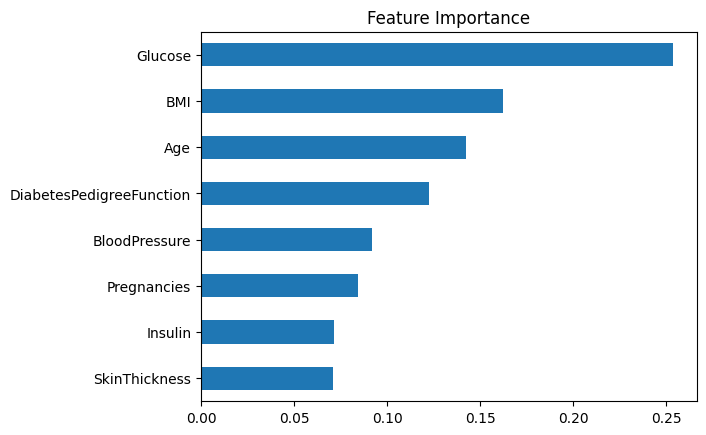

In [93]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 3. Preprocessing
- Tangani missing values dengan metode seperti imputasi (mean/median untuk numerik, mode untuk kategorikal) atau penghapusan baris/kolom jika diperlukan.
- Lakukan encoding untuk variabel kategorikal, misalnya menggunakan one-hot encoding atau label encoding.
- Normalisasi atau standarisasi fitur numerik untuk memastikan skala yang seragam, terutama jika menggunakan model berbasis jarak seperti KNN.
- Pisahkan dataset menjadi fitur (X) dan target (y), serta bagi menjadi data training dan testing (misalnya 80:20).
- Jika diperlukan, lakukan feature selection atau engineering untuk meningkatkan performa model.

In [94]:
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

data[cols] = data[cols].replace(0, np.nan)

In [95]:
for col in cols:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_1986/1366271820.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [96]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [97]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# split dulu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit hanya di train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# test hanya transform
X_test = scaler.transform(X_test)

## 4. Modelling
- Pilih dan implementasikan tiga model Supervised Learning: Decision Tree, Naive Bayes, dan KNN.
- Untuk Decision Tree: Gunakan algoritma pohon keputusan untuk klasifikasi atau regresi, atur parameter dasar seperti max_depth.
- Untuk Naive Bayes: Terapkan model probabilitas berbasis teorema Bayes, cocok untuk data kategorikal atau numerik dengan asumsi independensi fitur.
- Untuk KNN (K-Nearest Neighbors): Gunakan algoritma berbasis jarak, tentukan nilai K (jumlah tetangga) yang optimal.
- Latih masing-masing model menggunakan data training dan pastikan model dapat memprediksi data testing.

In [98]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [99]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test)

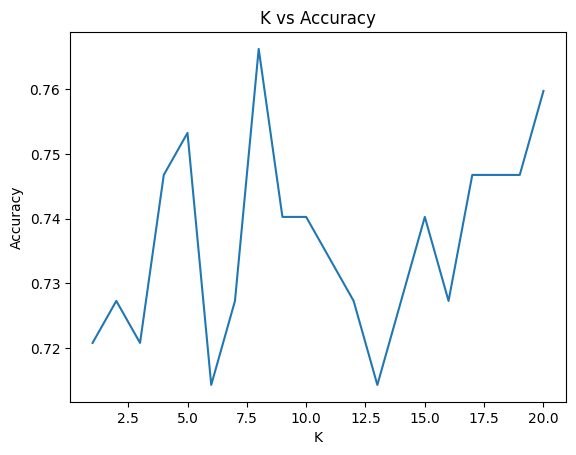

In [100]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(k_values, scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [101]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Decision Tree Accuracy: 0.6493506493506493
Naive Bayes Accuracy: 0.7012987012987013
KNN Accuracy: 0.7662337662337663


## 5. Eksperiment
- Lakukan Cross-Validation untuk mengevaluasi stabilitas model, misalnya menggunakan 5-fold atau 10-fold CV pada data training.
- Terapkan K-Fold Cross-Validation secara eksplisit untuk membagi data menjadi K subset dan hitung rata-rata performa.
- Lakukan Hyperparameter Tuning untuk setiap model, seperti mencari nilai optimal untuk max_depth di Decision Tree, K di KNN, atau parameter smoothing di Naive Bayes, menggunakan teknik seperti Grid Search atau Random Search.
- Bandingkan hasil eksperiment untuk menentukan konfigurasi terbaik bagi masing-masing model.

In [103]:
from sklearn.model_selection import cross_val_score

# Decision Tree
cv_dt = cross_val_score(dt, X_train, y_train, cv=5)

# Naive Bayes
cv_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5)

# KNN
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5)

print("DT CV:", cv_dt.mean())
print("NB CV:", cv_nb.mean())
print("KNN CV:", cv_knn.mean())

DT CV: 0.7247767559642809
NB CV: 0.7589764094362256
KNN CV: 0.7410902305744369


In [104]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    dt.fit(X_tr, y_tr)
    scores.append(dt.score(X_val, y_val))

print("Manual K-Fold DT:", np.mean(scores))

Manual K-Fold DT: 0.7442756230840997


In [105]:
from sklearn.model_selection import GridSearchCV

param_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5)
grid_dt.fit(X_train, y_train)

print("Best DT:", grid_dt.best_params_)

Best DT: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [106]:
param_knn = {
    "n_neighbors": range(1, 31),   # lebih luas
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # Manhattan vs Euclidean
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train)

print("Best KNN:", grid_knn.best_params_)

Best KNN: {'n_neighbors': 20, 'p': 2, 'weights': 'uniform'}


In [107]:
param_nb = {
    "var_smoothing": np.logspace(-12, -6, 20)
}
grid_nb = GridSearchCV(GaussianNB(), param_nb, cv=5)
grid_nb.fit(X_train_scaled, y_train)

print("Best NB:", grid_nb.best_params_)

Best NB: {'var_smoothing': np.float64(1e-12)}


In [108]:
from sklearn.model_selection import RandomizedSearchCV

random_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_knn,
    n_iter=20,  # coba 20 kombinasi saja
    cv=5,
    random_state=42
)

random_knn.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=20,
                   param_distributions={'n_neighbors': range(1, 31),
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42)

In [109]:
best_dt = grid_dt.best_estimator_
best_knn = grid_knn.best_estimator_
best_nb = grid_nb.best_estimator_

print("DT tuned:", best_dt.score(X_test, y_test))
print("KNN tuned:", best_knn.score(X_test, y_test))
print("NB tuned:", best_nb.score(X_test, y_test))

DT tuned: 0.6493506493506493
KNN tuned: 0.7597402597402597
NB tuned: 0.7012987012987013


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 6. Evaluasi
- Evaluasi performa model menggunakan metrik: Confusion Matrix (untuk melihat true positive, false positive, dll.), F1-Score (untuk balance antara precision dan recall), dan Akurasi (persentase prediksi benar).
- Hitung metrik ini untuk setiap model pada data testing, dan bandingkan hasilnya.
- Analisis hasil evaluasi untuk mengidentifikasi kekuatan dan kelemahan masing-masing model, seperti overfitting atau underfitting.

In [110]:
from sklearn.metrics import confusion_matrix, classification_report

print("=== KNN ===")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

print("=== Naive Bayes ===")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

print("=== Decision Tree ===")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

=== KNN ===
[[88 12]
 [24 30]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.71      0.56      0.62        54

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154

=== Naive Bayes ===
[[74 26]
 [20 34]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154

=== Decision Tree ===
[[100   0]
 [ 54   0]]
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       100
           1       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Rangkuman
Tulis apa saja yang kalian pelajari dari hands on ini. Jangan lupa follow ig @aryapratamars dan @cathleenn_